In [1]:
# Other way to interpolate by Remi
import sys
import os
import argparse
import yaml

import numpy as np

import xesmf
import xarray as xr
import xarray
with open('nep_ic-rst.yaml', 'r') as f:
    config = yaml.safe_load(f)

GOA_STATIC = "/archive/Remi.Pages/fre/Arc_12/2026_02.01/CGOA_BGC_2025_07_base_nep_phy_feb26/gfdl.ncrc6-intel23-prod/pp/ocean_daily/ocean_daily.static.nc"
NEP_STATIC = "/archive/Liz.Drenkard/fre/cefi/NEP/2025_07/NEP10k_202507_physics_bgc/gfdl.ncrc6-intel23-repro/pp/ocean_daily/ocean_daily.static.nc"

def regrid_tracer(fld, method='nearest_s2d'):
    coords = xr.open_dataset('/archive/Remi.Pages/fre/Arc_12/2026_02.01/CGOA_BGC_2025_07_base_nep_phy_feb26/gfdl.ncrc6-intel23-prod/pp/ocean_daily/ocean_daily.static.nc')
    coords = coords.rename({'geolon': 'lon', 'geolat': 'lat'})  # interp on this 
    gsource = xr.open_dataset('/archive/Liz.Drenkard/fre/cefi/NEP/2025_07/NEP10k_202507_physics_bgc/gfdl.ncrc6-intel23-repro/pp/ocean_daily/ocean_daily.static.nc',decode_times=False) # Source
    gsource = gsource.rename({'geolon': 'lon', 'geolat': 'lat'})  # interp on this 
    print(gsource)
    regrid = xesmf.Regridder(
        gsource,
        coords,
        method=method,
        periodic=False,
        filename='regrid_bilin.nc',
        reuse_weights=False
    )
    tdest = regrid(fld)
    return tdest
def regrid_u(fld, method='nearest_s2d'):
    coords = xr.open_dataset('/archive/Remi.Pages/fre/Arc_12/2026_02.01/CGOA_BGC_2025_07_base_nep_phy_feb26/gfdl.ncrc6-intel23-prod/pp/ocean_daily/ocean_daily.static.nc')
    coords = coords.rename({'geolon_u': 'lon', 'geolat_u': 'lat'})  # interp on this 
    gsource = xr.open_dataset('/archive/Liz.Drenkard/fre/cefi/NEP/2025_07/NEP10k_202507_physics_bgc/gfdl.ncrc6-intel23-repro/pp/ocean_daily/ocean_daily.static.nc',decode_times=False) # Source
    gsource = gsource.rename({'geolon_u': 'lon', 'geolat_u': 'lat'})  # interp on this 
    
    regrid = xesmf.Regridder(
        gsource,
        coords,
        method=method,
        periodic=False,
        filename='regrid_bilin_uu.nc',
        reuse_weights=False
    )
    tdest = regrid(fld)
    return tdest

def regrid_v(fld, method="nearest_s2d"):
    coords = xr.open_dataset(GOA_STATIC)
    coords = coords.rename({"geolon_v": "lon", "geolat_v": "lat"})
    gsource = xr.open_dataset(NEP_STATIC, decode_times=False)
    gsource = gsource.rename({"geolon_v": "lon", "geolat_v": "lat"})

    regrid = xesmf.Regridder(
        gsource, coords,
        method=method,
        periodic=False,
        filename="regrid_bilin_vv.nc",
        reuse_weights=False,
    )
    return regrid(fld)


# Use the functions
variable_names = config.get('variable_names', {})
temp_var = variable_names.get('temperature', 'Temp')
sal_var = variable_names.get('salinity', 'Salt')
ssh_var = variable_names.get('sea_surface_height', 'zos')
u_var = variable_names.get('zonal_velocity', 'u')
v_var = variable_names.get('meridional_velocity', 'v')


nep = (
    xarray.open_dataset('/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/19940101crpt_forc/ocean_month_z.nc',decode_times=False)
    [[temp_var, sal_var, u_var, v_var]])
nep_ssh = (
    xarray.open_dataset('/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/19940101crpt_forc/ocean_month.nc',decode_times=False)
    [[ssh_var]])

# === Regrid to MOM6 Grid ===
print('Start ssh')
regridded_ssh = regrid_tracer(nep_ssh['zos'], method='nearest_s2d')  # Should return (time, depth, J, I)

#regridded = regrid_tracer(nep[temp_var], method='nearest_s2d')  # Should return (time, depth, J, I)
#regridded_u = regrid_u(nep[u_var], method='nearest_s2d')  # Should return (time, depth, J, I)
#regridded_v = regrid_v(nep[v_var], method="nearest_s2d")
#print("regridded_v dims:", regridded_v.dims)


Start ssh
<xarray.Dataset> Size: 28MB
Dimensions:       (jq: 817, iq: 343, jh: 816, ih: 342)
Coordinates:
  * ih            (ih) float64 3kB 0.5 1.5 2.5 3.5 ... 338.5 339.5 340.5 341.5
  * iq            (iq) float64 3kB 0.0 1.0 2.0 3.0 ... 339.0 340.0 341.0 342.0
  * jh            (jh) float64 7kB 0.5 1.5 2.5 3.5 ... 812.5 813.5 814.5 815.5
  * jq            (jq) float64 7kB 0.0 1.0 2.0 3.0 ... 813.0 814.0 815.0 816.0
Data variables: (12/25)
    Coriolis      (jq, iq) float32 1MB ...
    areacello     (jh, ih) float32 1MB ...
    areacello_bu  (jq, iq) float32 1MB ...
    areacello_cu  (jh, iq) float32 1MB ...
    areacello_cv  (jq, ih) float32 1MB ...
    deptho        (jh, ih) float32 1MB ...
    ...            ...
    geolon_v      (jq, ih) float32 1MB ...
    sftof         (jh, ih) float32 1MB ...
    wet           (jh, ih) float32 1MB ...
    wet_c         (jq, iq) float32 1MB ...
    wet_u         (jh, iq) float32 1MB ...
    wet_v         (jq, ih) float32 1MB ...
Attributes:
   

/nbhome/role.medgrp/.conda/envs/medpy311/lib/python3.11/site-packages/xesmf/frontend.py:718: UserWarning: Using dimensions ('yh', 'xh') from data variable zos as the horizontal dimensions for the regridding.
  warnings.warn(


In [65]:
ssh_var

'zos'

In [29]:
# ============================================================
# Basemap Setup Function for NEP10 Domain
# ============================================================
def setup_basemap_nep(ax, title, label_pos="none", title_on=True):
    """
    Initialize a NEP10 Mercator Basemap
    with customizable label positions.

    NEP domain uses 0–360 longitude convention
    (e.g., 229–255 degE).

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axis to plot the basemap on.
    title : str
        Title of the subplot.
    label_pos : str
        "none"   -> no labels (default)
        "left"   -> labels on left only
        "bottom" -> labels on bottom only
        "both"   -> labels on left and bottom
    title_on : bool
        Whether to display the title.
    """

    label_dict = {
        "left":   [1, 0, 0, 0],
        "bottom": [0, 0, 0, 1],
        "both":   [1, 0, 0, 1],
        "none":   [0, 0, 0, 0]
    }
    labels = label_dict.get(label_pos, [0, 0, 0, 0])

    # --- NEP10 domain (native lon convention 0–360) ---
    llcrnrlon = 190
    urcrnrlon = 240
    llcrnrlat = 48
    urcrnrlat = 62

    m = Basemap(
        projection='merc',
        llcrnrlon=llcrnrlon,
        urcrnrlon=urcrnrlon,
        llcrnrlat=llcrnrlat,
        urcrnrlat=urcrnrlat,
        resolution='i',
        ax=ax
    )

    m.drawcoastlines()
    m.drawcountries()
    m.drawmapboundary(fill_color="white")
    m.fillcontinents(color="lightgray", lake_color="lightblue")

    # Meridians in 0–360 convention
    m.drawparallels(np.arange(10, 70, 10), labels=labels, linewidth=0.02)
    m.drawmeridians(np.arange(220, 270, 10), labels=labels, linewidth=0.02)

    if title_on:
        ax.set_title(title)

    return m
# === Plotting Libraries ===
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# ============================================================
# Basemap Setup Function for Gulf of Alaska (GoA)
# ============================================================
def setup_basemap(ax, title, label_pos="none", title_on=True):
    """
    Initialize a Gulf of Alaska (GoA) Lambert Conformal Basemap
    with customizable label positions.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axis to plot the basemap on.
    title : str
        Title of the subplot.
    label_pos : str
        Position of latitude/longitude labels:
        "none"   -> no labels (default)
        "left"   -> labels on left only
        "bottom" -> labels on bottom only
        "both"   -> labels on left and bottom
    title_on : bool
        Whether to display the title.
    """

    label_dict = {
        "left":   [1, 0, 0, 0],
        "bottom": [0, 0, 0, 1],
        "both":   [1, 0, 0, 1],
        "none":   [0, 0, 0, 0]
    }
    labels = label_dict.get(label_pos, [0, 0, 0, 0])

    # --- Gulf of Alaska domain (approx) ---
    llcrnrlon = -160
    urcrnrlon = -130
    llcrnrlat = 48
    urcrnrlat = 62

    m = Basemap(projection='merc',
             llcrnrlon=-160, urcrnrlon=-130,
             llcrnrlat=48, urcrnrlat=62,
             resolution='i', ax=ax)


    m.drawcoastlines()
    m.drawcountries()
    m.drawmapboundary(fill_color="white")
    m.fillcontinents(color="lightgray", lake_color="lightblue")

    m.drawparallels(np.arange(48, 65, 5), labels=labels, linewidth=0.02)
    m.drawmeridians(np.arange(-170, -120, 10), labels=labels, linewidth=0.02)

    if title_on:
        ax.set_title(title)

    return m


(528, 480) (3, 528, 480)
(816, 342) (3, 816, 342)


/vftmp/Remi.Pages/pid218228/ipykernel_238825/3684720176.py:39: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im1=ax1.pcolormesh(x_bm, y_bm,regridded_ssh[0,:,:]*wet_u, cmap='coolwarm', vmin=-vmax, vmax=vmax)
/vftmp/Remi.Pages/pid218228/ipykernel_238825/3684720176.py:44: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax2.pcolormesh(x_bm, y_bm,nep_ssh[ssh_var][0,:,:]*wet_u_nep, cmap='coolwarm', vmin=-vmax, vmax=vmax)


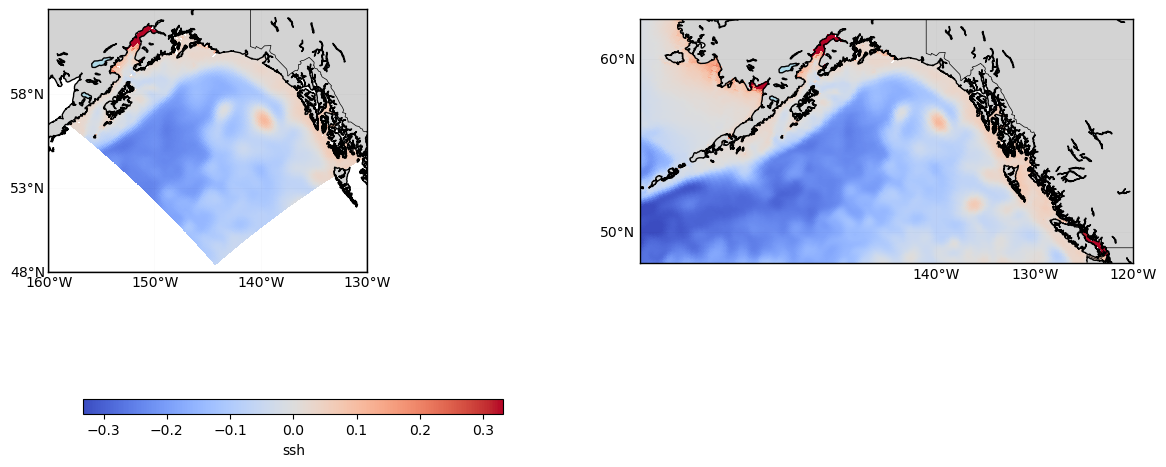

In [35]:
GOA_STATIC = "/archive/Remi.Pages/fre/Arc_12/2026_02.01/CGOA_BGC_2025_07_base_nep_phy_feb26/gfdl.ncrc6-intel23-prod/pp/ocean_daily/ocean_daily.static.nc"
NEP_STATIC = "/archive/Liz.Drenkard/fre/cefi/NEP/2025_07/NEP10k_202507_physics_bgc/gfdl.ncrc6-intel23-repro/pp/ocean_daily/ocean_daily.static.nc"


goa = xr.open_dataset(GOA_STATIC, decode_times=False)
lon_goa=np.array(goa['geolon'])
lon_goa[np.isnan(lon_goa)==True]=0
lat_goa=np.array(goa['geolat'])
lat_goa[np.isnan(lat_goa)==True]=0
wet_u=np.array(goa['wet'])
wet_u[wet_u[:]==0]=np.nan

print(lat_goa.shape,regridded_ssh.shape)


nep_grid = xr.open_dataset(NEP_STATIC, decode_times=False)


lon_nep = np.array(nep_grid["geolon"])

lon_nep[np.isnan(lon_nep)==True]=0
lat_nep=np.array(nep_grid['geolat'])
lat_nep[np.isnan(lat_nep)==True]=0
wet_u_nep=np.array(nep_grid['wet'])
wet_u_nep[wet_u_nep[:]==0]=np.nan

print(lat_nep.shape,nep_ssh[ssh_var].shape)


vmax = np.nanpercentile(np.abs(nep_ssh[ssh_var][0,:,:]*wet_u_nep), 80)
vmax = max(vmax, np.nanpercentile(np.abs(regridded_ssh[0,:,:]*wet_u), 80))


fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 3, 1)
m1 = setup_basemap(ax1, '','both')
x_bm, y_bm = m1(lon_goa, lat_goa)
im1=ax1.pcolormesh(x_bm, y_bm,regridded_ssh[0,:,:]*wet_u, cmap='coolwarm', vmin=-vmax, vmax=vmax)

ax2 = fig.add_subplot(1, 2, 2)
m2 = setup_basemap_nep(ax2, '','both')
x_bm, y_bm = m2(lon_nep, lat_nep)
ax2.pcolormesh(x_bm, y_bm,nep_ssh[ssh_var][0,:,:]*wet_u_nep, cmap='coolwarm', vmin=-vmax, vmax=vmax)

cbar_ax = fig.add_axes([0.15, 0.04, 0.3, 0.025])
cbar = fig.colorbar(im1, cax=cbar_ax, orientation='horizontal')
cbar.set_label('ssh')


In [10]:
lat.shape

(528, 480)

=== Diagnostics ===
OBC file: ./outputs_CGOA_feb26/zos_001_1994.nc
OBC zos var: zos_segment_001
OBC zos dims: ('time', 'ny_segment_001', 'nx_segment_001') shape: (3, 1, 961)
OBC lon dims: ('nx_segment_001',) shape: (961,)
OBC lat dims: ('nx_segment_001',) shape: (961,)
OBC strip?: True across_dim: ny_segment_001 along_dim: nx_segment_001
Full-field dims: ('jh', 'ih') shape: (528, 480)
Full-field edge length: 480 border: south ydim/xdim: ('jh', 'ih')

=== Best alignment ===
Chosen: strip_side_0
Downsample/reversal: ('odd', 'edge') (even/odd, edge/edge_rev)
RMS: 0.0050105723
Compared length: 480



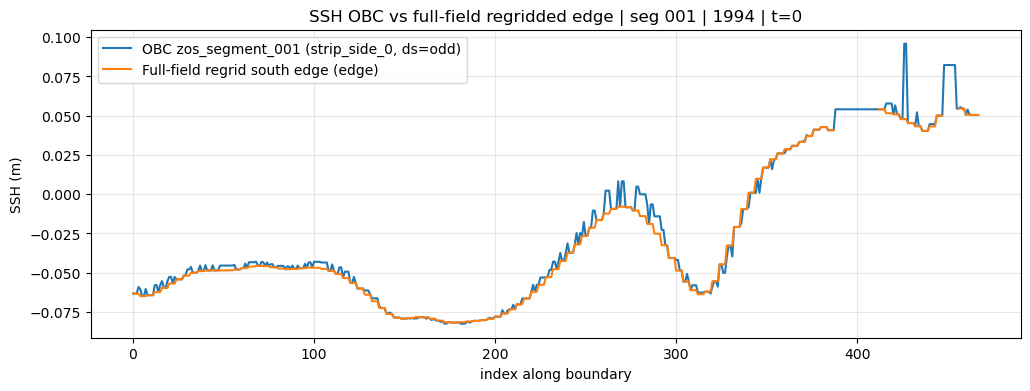

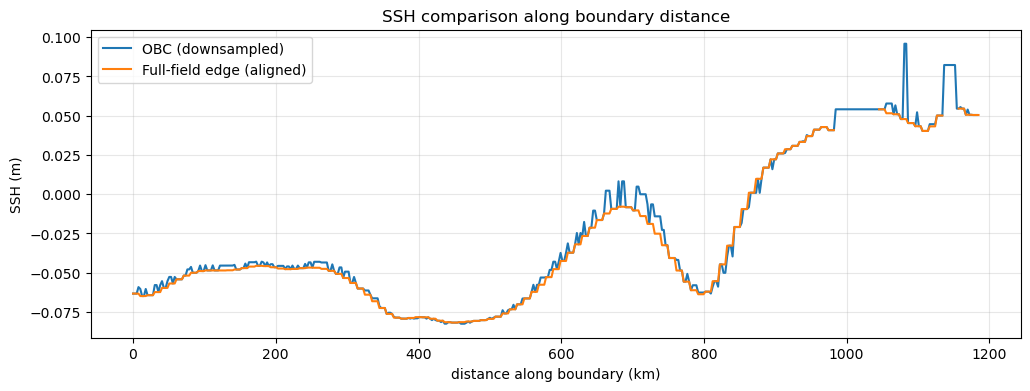

In [70]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================
# User settings
# ==========================
YEAR = 1994
TIME_INDEX = 0
SEG = "001"
BORDER = "south"   # "south" | "north" | "east" | "west"

OBC_FILE = f"./outputs_CGOA_feb26/zos_{int(SEG):03d}_{YEAR}.nc"
STATIC_FILE = "/archive/Remi.Pages/fre/Arc_12/2026_02.01/CGOA_BGC_2025_07_base_nep_phy_feb26/gfdl.ncrc6-intel23-prod/pp/ocean_daily/ocean_daily.static.nc"

# Expect: regridded_ssh is already in memory (xarray DataArray)

# ==========================
# Helpers
# ==========================
def rms(a, b):
    return np.sqrt(np.nanmean((a - b) ** 2))

def trim_to_common(a, b):
    n = min(len(a), len(b))
    return a[:n], b[:n]

def haversine_km(lon, lat):
    R = 6371.0
    lon = np.asarray(lon)
    lat = np.asarray(lat)
    lonr = np.deg2rad(lon)
    latr = np.deg2rad(lat)
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat / 2) ** 2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon / 2) ** 2
    d = 2 * R * np.arcsin(np.sqrt(a))
    return np.concatenate([[0.0], np.cumsum(d)])

def extract_fullfield_edge(zos_full, border):
    """Extract 1D edge from full-field DataArray; assumes last two dims are (y, x)."""
    ydim, xdim = zos_full.dims[-2], zos_full.dims[-1]
    b = border.lower()
    if b == "east":
        edge = zos_full.isel({xdim: -1})
    elif b == "west":
        edge = zos_full.isel({xdim: 0})
    elif b == "south":
        edge = zos_full.isel({ydim: 0})
    elif b == "north":
        edge = zos_full.isel({ydim: -1})
    else:
        raise ValueError("border must be one of: south, north, east, west")
    return edge.values.reshape(-1), (ydim, xdim)

def _isel_if_dim(da, dim, idx):
    """isel only if dim exists in DataArray dims."""
    return da.isel({dim: idx}) if dim in da.dims else da

def extract_obc_candidates(ds_o, zos_name, lon_name, lat_name, time_index=0):
    """
    Returns two candidate OBC 1D lines (side 0 and side -1 of strip) plus lon/lat (1D).
    Handles:
      - zos 1D
      - zos 2D strip
      - lon/lat 1D or 2D
    """
    zos_da = ds_o[zos_name]
    lon_da = ds_o[lon_name]
    lat_da = ds_o[lat_name]

    # subset time if present
    zos_da = _isel_if_dim(zos_da, "time", time_index)
    lon_da = _isel_if_dim(lon_da, "time", time_index)
    lat_da = _isel_if_dim(lat_da, "time", time_index)

    # segment dims of zos (excluding time)
    seg_dims = [d for d in zos_da.dims if d != "time"]

    if len(seg_dims) == 1:
        # already 1D
        line = zos_da.values.reshape(-1)
        # lon/lat could be 1D or more; flatten to 1D
        lon1 = lon_da.values.reshape(-1)
        lat1 = lat_da.values.reshape(-1)
        return {
            "is_strip": False,
            "across_dim": None,
            "along_dim": seg_dims[0],
            "line0": line,
            "line1": line,
            "lon": lon1,
            "lat": lat1,
        }

    if len(seg_dims) != 2:
        raise ValueError(f"Unexpected zos dims {zos_da.dims}; expected 1D or 2D strip.")

    d0, d1 = seg_dims
    n0, n1 = zos_da.sizes[d0], zos_da.sizes[d1]

    # across = smaller dim, along = larger dim
    if n0 <= n1:
        across_dim, along_dim = d0, d1
    else:
        across_dim, along_dim = d1, d0

    # Two candidate boundary lines (side 0 and side -1)
    line0 = zos_da.isel({across_dim: 0}).values.reshape(-1)
    line1 = zos_da.isel({across_dim: -1}).values.reshape(-1)

    # lon/lat handling:
    # If lon/lat are 2D and include across_dim, slice like zos.
    # If lon/lat are 1D (your case), just flatten.
    lon0_da = lon_da
    lat0_da = lat_da
    lon1_da = lon_da
    lat1_da = lat_da

    if across_dim in lon_da.dims:
        lon0_da = lon_da.isel({across_dim: 0})
        lon1_da = lon_da.isel({across_dim: -1})
    if across_dim in lat_da.dims:
        lat0_da = lat_da.isel({across_dim: 0})
        lat1_da = lat_da.isel({across_dim: -1})

    lon0 = lon0_da.values.reshape(-1)
    lat0 = lat0_da.values.reshape(-1)
    lon1 = lon1_da.values.reshape(-1)
    lat1 = lat1_da.values.reshape(-1)

    # If lon/lat are longer than the along-line (can happen if flattened 2D),
    # trim them to match the line length.
    lon0 = lon0[: len(line0)]
    lat0 = lat0[: len(line0)]
    lon1 = lon1[: len(line1)]
    lat1 = lat1[: len(line1)]

    return {
        "is_strip": True,
        "across_dim": across_dim,
        "along_dim": along_dim,
        "line0": line0,
        "line1": line1,
        "lon0": lon0,
        "lat0": lat0,
        "lon1": lon1,
        "lat1": lat1,
    }

def find_best_alignment(obc_line, edge_1d):
    """
    Try:
      - supergrid parity: 0::2 vs 1::2
      - edge direction: forward vs reversed
    Return best-aligned arrays + label + score.
    """
    edge = edge_1d

    even = obc_line[0::2]
    odd  = obc_line[1::2]

    e0, ed = trim_to_common(even, edge)
    o0, od = trim_to_common(odd,  edge)

    ed_r = ed[::-1]
    od_r = od[::-1]

    candidates = {
        ("even", "edge"):     (e0, ed),
        ("even", "edge_rev"): (e0, ed_r),
        ("odd",  "edge"):     (o0, od),
        ("odd",  "edge_rev"): (o0, od_r),
    }

    scores = {k: rms(v[0], v[1]) for k, v in candidates.items()}
    best_k = min(scores, key=scores.get)
    return candidates[best_k][0], candidates[best_k][1], best_k, scores[best_k]

# ==========================
# Load OBC and find variable names
# ==========================
ds_o = xr.open_dataset(OBC_FILE, decode_times=False)

zos_name = next(v for v in ds_o.data_vars if "zos" in v.lower())
lon_name = next(v for v in ds_o.variables if "lon" in v.lower())
lat_name = next(v for v in ds_o.variables if "lat" in v.lower())

# ==========================
# Full-field edge from regridded_ssh
# ==========================
zos_full = regridded_ssh.isel(time=TIME_INDEX)
zos_edge_1d, (ydim, xdim) = extract_fullfield_edge(zos_full, BORDER)

# ==========================
# OBC candidates (strip side 0 vs -1)
# ==========================
obc = extract_obc_candidates(ds_o, zos_name, lon_name, lat_name, time_index=TIME_INDEX)

print("=== Diagnostics ===")
print("OBC file:", OBC_FILE)
print("OBC zos var:", zos_name)
print("OBC zos dims:", ds_o[zos_name].dims, "shape:", ds_o[zos_name].shape)
print("OBC lon dims:", ds_o[lon_name].dims, "shape:", ds_o[lon_name].shape)
print("OBC lat dims:", ds_o[lat_name].dims, "shape:", ds_o[lat_name].shape)
print("OBC strip?:", obc["is_strip"], "across_dim:", obc.get("across_dim"), "along_dim:", obc.get("along_dim"))
print("Full-field dims:", zos_full.dims, "shape:", zos_full.shape)
print("Full-field edge length:", len(zos_edge_1d), "border:", BORDER, "ydim/xdim:", (ydim, xdim))
print()

# ==========================
# Choose best match (strip side + parity + reversal)
# ==========================
best = {"score": np.inf}

if not obc["is_strip"]:
    # single line case
    obc_line = obc["line0"]
    obc_T, edge_T, which, score = find_best_alignment(obc_line, zos_edge_1d)
    best.update({
        "label": "1D",
        "obc_T": obc_T,
        "edge_T": edge_T,
        "which": which,
        "score": score,
        "lon": obc["lon"][: len(obc_T)],
        "lat": obc["lat"][: len(obc_T)],
    })
else:
    for side in ["0", "-1"]:
        obc_line = obc["line0"] if side == "0" else obc["line1"]
        lon_line = obc["lon0"]  if side == "0" else obc["lon1"]
        lat_line = obc["lat0"]  if side == "0" else obc["lat1"]

        obc_T, edge_T, which, score = find_best_alignment(obc_line, zos_edge_1d)

        # lon/lat downsample in same way (even/odd)
        lon_ds = lon_line[0::2] if which[0] == "even" else lon_line[1::2]
        lat_ds = lat_line[0::2] if which[0] == "even" else lat_line[1::2]

        lon_ds = lon_ds[: len(obc_T)]
        lat_ds = lat_ds[: len(obc_T)]

        if score < best["score"]:
            best.update({
                "label": f"strip_side_{side}",
                "obc_T": obc_T,
                "edge_T": edge_T,
                "which": which,
                "score": score,
                "lon": lon_ds,
                "lat": lat_ds,
            })

print("=== Best alignment ===")
print("Chosen:", best["label"])
print("Downsample/reversal:", best["which"], "(even/odd, edge/edge_rev)")
print("RMS:", best["score"])
print("Compared length:", len(best["obc_T"]))
print()

# ==========================
# Plot (index)
# ==========================
plt.figure(figsize=(12, 4))
plt.plot(best["obc_T"], label=f"OBC {zos_name} ({best['label']}, ds={best['which'][0]})")
plt.plot(best["edge_T"], label=f"Full-field regrid {BORDER} edge ({best['which'][1]})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel("index along boundary")
plt.ylabel("SSH (m)")
plt.title(f"SSH OBC vs full-field regridded edge | seg {SEG} | {YEAR} | t={TIME_INDEX}")
plt.show()

# ==========================
# Plot (distance in km using OBC lon/lat)
# ==========================
try:
    s_km = haversine_km(best["lon"], best["lat"])
    plt.figure(figsize=(12, 4))
    plt.plot(s_km, best["obc_T"], label="OBC (downsampled)")
    plt.plot(s_km, best["edge_T"], label="Full-field edge (aligned)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlabel("distance along boundary (km)")
    plt.ylabel("SSH (m)")
    plt.title("SSH comparison along boundary distance")
    plt.show()
except Exception as e:
    print("Distance plot skipped (lon/lat issue):", e)

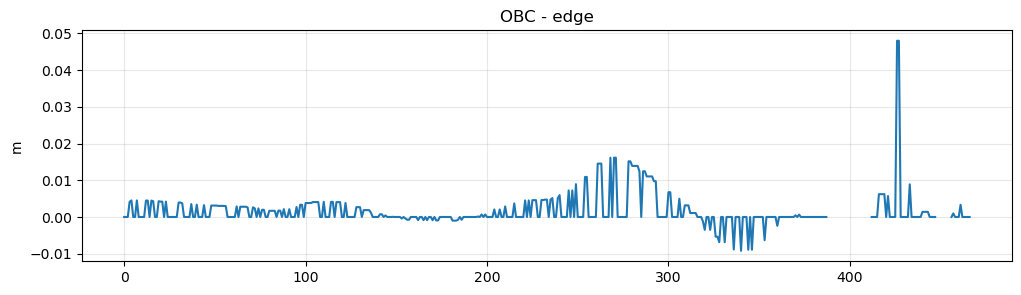

max abs diff: 0.047988597
idx of max: 426


In [68]:
diff = best["obc_T"] - best["edge_T"]
plt.figure(figsize=(12,3))
plt.plot(diff); plt.grid(True, alpha=0.3)
plt.title("OBC - edge"); plt.ylabel("m")
plt.show()

print("max abs diff:", np.nanmax(np.abs(diff)))
print("idx of max:", np.nanargmax(np.abs(diff)))

In [69]:
i = np.nanargmax(np.abs(diff))
print("lon/lat at max diff:", best["lon"][i], best["lat"][i], "diff:", diff[i])

lon/lat at max diff: -131.7154083251953 54.192283630371094 diff: 0.047988597


=== Diagnostics ===
OBC file: ./outputs_CGOA_feb26/zos_002_1994.nc
OBC zos var: zos_segment_002
OBC zos dims: ('time', 'ny_segment_002', 'nx_segment_002') shape: (3, 1057, 1)
OBC lon dims: ('ny_segment_002',) shape: (1057,)
OBC lat dims: ('ny_segment_002',) shape: (1057,)
OBC strip?: True across_dim: nx_segment_002 along_dim: ny_segment_002
Full-field dims: ('jh', 'ih') shape: (528, 480)
Full-field edge length: 528 border: west ydim/xdim: ('jh', 'ih')

=== Best alignment ===
Chosen: strip_side_0
Downsample/reversal: ('odd', 'edge') (even/odd, edge/edge_rev)
RMS: 0.002328436
Compared length: 528



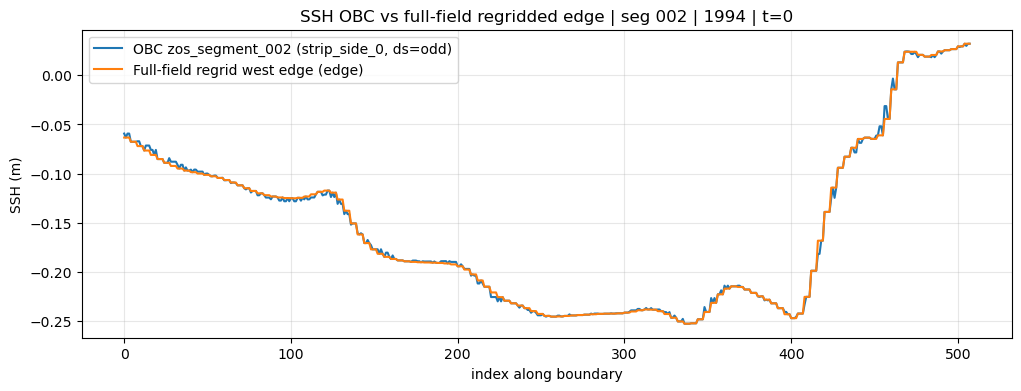

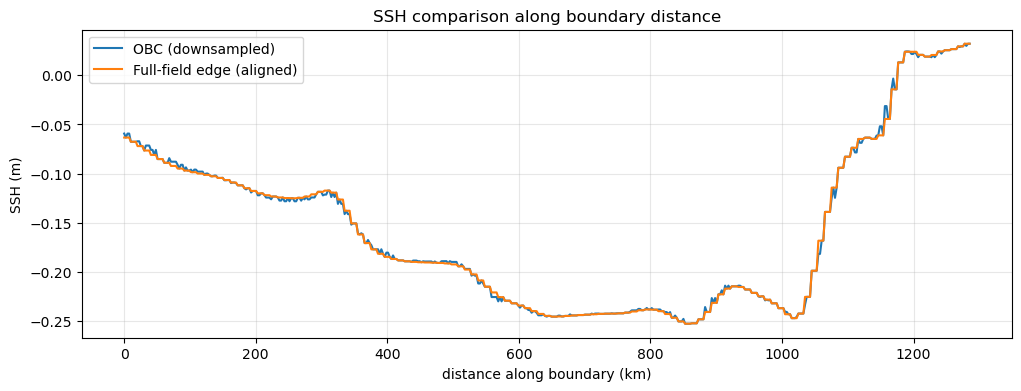

In [71]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================
# User settings
# ==========================
YEAR = 1994
TIME_INDEX = 0
SEG = "002"
BORDER = "west"   # "south" | "north" | "east" | "west"

OBC_FILE = f"./outputs_CGOA_feb26/zos_{int(SEG):03d}_{YEAR}.nc"
STATIC_FILE = "/archive/Remi.Pages/fre/Arc_12/2026_02.01/CGOA_BGC_2025_07_base_nep_phy_feb26/gfdl.ncrc6-intel23-prod/pp/ocean_daily/ocean_daily.static.nc"

# Expect: regridded_ssh is already in memory (xarray DataArray)

# ==========================
# Helpers
# ==========================
def rms(a, b):
    return np.sqrt(np.nanmean((a - b) ** 2))

def trim_to_common(a, b):
    n = min(len(a), len(b))
    return a[:n], b[:n]

def haversine_km(lon, lat):
    R = 6371.0
    lon = np.asarray(lon)
    lat = np.asarray(lat)
    lonr = np.deg2rad(lon)
    latr = np.deg2rad(lat)
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat / 2) ** 2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon / 2) ** 2
    d = 2 * R * np.arcsin(np.sqrt(a))
    return np.concatenate([[0.0], np.cumsum(d)])

def extract_fullfield_edge(zos_full, border):
    """Extract 1D edge from full-field DataArray; assumes last two dims are (y, x)."""
    ydim, xdim = zos_full.dims[-2], zos_full.dims[-1]
    b = border.lower()
    if b == "east":
        edge = zos_full.isel({xdim: -1})
    elif b == "west":
        edge = zos_full.isel({xdim: 0})
    elif b == "south":
        edge = zos_full.isel({ydim: 0})
    elif b == "north":
        edge = zos_full.isel({ydim: -1})
    else:
        raise ValueError("border must be one of: south, north, east, west")
    return edge.values.reshape(-1), (ydim, xdim)

def _isel_if_dim(da, dim, idx):
    """isel only if dim exists in DataArray dims."""
    return da.isel({dim: idx}) if dim in da.dims else da

def extract_obc_candidates(ds_o, zos_name, lon_name, lat_name, time_index=0):
    """
    Returns two candidate OBC 1D lines (side 0 and side -1 of strip) plus lon/lat (1D).
    Handles:
      - zos 1D
      - zos 2D strip
      - lon/lat 1D or 2D
    """
    zos_da = ds_o[zos_name]
    lon_da = ds_o[lon_name]
    lat_da = ds_o[lat_name]

    # subset time if present
    zos_da = _isel_if_dim(zos_da, "time", time_index)
    lon_da = _isel_if_dim(lon_da, "time", time_index)
    lat_da = _isel_if_dim(lat_da, "time", time_index)

    # segment dims of zos (excluding time)
    seg_dims = [d for d in zos_da.dims if d != "time"]

    if len(seg_dims) == 1:
        # already 1D
        line = zos_da.values.reshape(-1)
        # lon/lat could be 1D or more; flatten to 1D
        lon1 = lon_da.values.reshape(-1)
        lat1 = lat_da.values.reshape(-1)
        return {
            "is_strip": False,
            "across_dim": None,
            "along_dim": seg_dims[0],
            "line0": line,
            "line1": line,
            "lon": lon1,
            "lat": lat1,
        }

    if len(seg_dims) != 2:
        raise ValueError(f"Unexpected zos dims {zos_da.dims}; expected 1D or 2D strip.")

    d0, d1 = seg_dims
    n0, n1 = zos_da.sizes[d0], zos_da.sizes[d1]

    # across = smaller dim, along = larger dim
    if n0 <= n1:
        across_dim, along_dim = d0, d1
    else:
        across_dim, along_dim = d1, d0

    # Two candidate boundary lines (side 0 and side -1)
    line0 = zos_da.isel({across_dim: 0}).values.reshape(-1)
    line1 = zos_da.isel({across_dim: -1}).values.reshape(-1)

    # lon/lat handling:
    # If lon/lat are 2D and include across_dim, slice like zos.
    # If lon/lat are 1D (your case), just flatten.
    lon0_da = lon_da
    lat0_da = lat_da
    lon1_da = lon_da
    lat1_da = lat_da

    if across_dim in lon_da.dims:
        lon0_da = lon_da.isel({across_dim: 0})
        lon1_da = lon_da.isel({across_dim: -1})
    if across_dim in lat_da.dims:
        lat0_da = lat_da.isel({across_dim: 0})
        lat1_da = lat_da.isel({across_dim: -1})

    lon0 = lon0_da.values.reshape(-1)
    lat0 = lat0_da.values.reshape(-1)
    lon1 = lon1_da.values.reshape(-1)
    lat1 = lat1_da.values.reshape(-1)

    # If lon/lat are longer than the along-line (can happen if flattened 2D),
    # trim them to match the line length.
    lon0 = lon0[: len(line0)]
    lat0 = lat0[: len(line0)]
    lon1 = lon1[: len(line1)]
    lat1 = lat1[: len(line1)]

    return {
        "is_strip": True,
        "across_dim": across_dim,
        "along_dim": along_dim,
        "line0": line0,
        "line1": line1,
        "lon0": lon0,
        "lat0": lat0,
        "lon1": lon1,
        "lat1": lat1,
    }

def find_best_alignment(obc_line, edge_1d):
    """
    Try:
      - supergrid parity: 0::2 vs 1::2
      - edge direction: forward vs reversed
    Return best-aligned arrays + label + score.
    """
    edge = edge_1d

    even = obc_line[0::2]
    odd  = obc_line[1::2]

    e0, ed = trim_to_common(even, edge)
    o0, od = trim_to_common(odd,  edge)

    ed_r = ed[::-1]
    od_r = od[::-1]

    candidates = {
        ("even", "edge"):     (e0, ed),
        ("even", "edge_rev"): (e0, ed_r),
        ("odd",  "edge"):     (o0, od),
        ("odd",  "edge_rev"): (o0, od_r),
    }

    scores = {k: rms(v[0], v[1]) for k, v in candidates.items()}
    best_k = min(scores, key=scores.get)
    return candidates[best_k][0], candidates[best_k][1], best_k, scores[best_k]

# ==========================
# Load OBC and find variable names
# ==========================
ds_o = xr.open_dataset(OBC_FILE, decode_times=False)

zos_name = next(v for v in ds_o.data_vars if "zos" in v.lower())
lon_name = next(v for v in ds_o.variables if "lon" in v.lower())
lat_name = next(v for v in ds_o.variables if "lat" in v.lower())

# ==========================
# Full-field edge from regridded_ssh
# ==========================
zos_full = regridded_ssh.isel(time=TIME_INDEX)
zos_edge_1d, (ydim, xdim) = extract_fullfield_edge(zos_full, BORDER)

# ==========================
# OBC candidates (strip side 0 vs -1)
# ==========================
obc = extract_obc_candidates(ds_o, zos_name, lon_name, lat_name, time_index=TIME_INDEX)

print("=== Diagnostics ===")
print("OBC file:", OBC_FILE)
print("OBC zos var:", zos_name)
print("OBC zos dims:", ds_o[zos_name].dims, "shape:", ds_o[zos_name].shape)
print("OBC lon dims:", ds_o[lon_name].dims, "shape:", ds_o[lon_name].shape)
print("OBC lat dims:", ds_o[lat_name].dims, "shape:", ds_o[lat_name].shape)
print("OBC strip?:", obc["is_strip"], "across_dim:", obc.get("across_dim"), "along_dim:", obc.get("along_dim"))
print("Full-field dims:", zos_full.dims, "shape:", zos_full.shape)
print("Full-field edge length:", len(zos_edge_1d), "border:", BORDER, "ydim/xdim:", (ydim, xdim))
print()

# ==========================
# Choose best match (strip side + parity + reversal)
# ==========================
best = {"score": np.inf}

if not obc["is_strip"]:
    # single line case
    obc_line = obc["line0"]
    obc_T, edge_T, which, score = find_best_alignment(obc_line, zos_edge_1d)
    best.update({
        "label": "1D",
        "obc_T": obc_T,
        "edge_T": edge_T,
        "which": which,
        "score": score,
        "lon": obc["lon"][: len(obc_T)],
        "lat": obc["lat"][: len(obc_T)],
    })
else:
    for side in ["0", "-1"]:
        obc_line = obc["line0"] if side == "0" else obc["line1"]
        lon_line = obc["lon0"]  if side == "0" else obc["lon1"]
        lat_line = obc["lat0"]  if side == "0" else obc["lat1"]

        obc_T, edge_T, which, score = find_best_alignment(obc_line, zos_edge_1d)

        # lon/lat downsample in same way (even/odd)
        lon_ds = lon_line[0::2] if which[0] == "even" else lon_line[1::2]
        lat_ds = lat_line[0::2] if which[0] == "even" else lat_line[1::2]

        lon_ds = lon_ds[: len(obc_T)]
        lat_ds = lat_ds[: len(obc_T)]

        if score < best["score"]:
            best.update({
                "label": f"strip_side_{side}",
                "obc_T": obc_T,
                "edge_T": edge_T,
                "which": which,
                "score": score,
                "lon": lon_ds,
                "lat": lat_ds,
            })

print("=== Best alignment ===")
print("Chosen:", best["label"])
print("Downsample/reversal:", best["which"], "(even/odd, edge/edge_rev)")
print("RMS:", best["score"])
print("Compared length:", len(best["obc_T"]))
print()

# ==========================
# Plot (index)
# ==========================
plt.figure(figsize=(12, 4))
plt.plot(best["obc_T"], label=f"OBC {zos_name} ({best['label']}, ds={best['which'][0]})")
plt.plot(best["edge_T"], label=f"Full-field regrid {BORDER} edge ({best['which'][1]})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel("index along boundary")
plt.ylabel("SSH (m)")
plt.title(f"SSH OBC vs full-field regridded edge | seg {SEG} | {YEAR} | t={TIME_INDEX}")
plt.show()

# ==========================
# Plot (distance in km using OBC lon/lat)
# ==========================
try:
    s_km = haversine_km(best["lon"], best["lat"])
    plt.figure(figsize=(12, 4))
    plt.plot(s_km, best["obc_T"], label="OBC (downsampled)")
    plt.plot(s_km, best["edge_T"], label="Full-field edge (aligned)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlabel("distance along boundary (km)")
    plt.ylabel("SSH (m)")
    plt.title("SSH comparison along boundary distance")
    plt.show()
except Exception as e:
    print("Distance plot skipped (lon/lat issue):", e)